# Jarvis Data Analytics
## Vehicle Sales Data
#### Authors: Gautam Ajit, Salah Salah

# ELT Pipeline (Extract, Load, Transform)

## Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [ ]:
cars_df = pd.read_csv("/content/car_prices.csv")
cars_df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## Dataset Size and Structure

**Dataset columns:**
| Column | Description |
|---|---|
| `year` | Model year of the vehicle |
| `make` | Brand (e.g. Ford, BMW) |
| `model` | Model name |
| `trim` | Trim level |
| `body` | Body type (SUV, Sedan, etc.) |
| `transmission` | Automatic / manual |
| `vin` | Vehicle identification number |
| `state` | US state where sold |
| `condition` | Condition score (1–49) |
| `odometer` | Mileage at time of sale |
| `color` | Exterior color |
| `interior` | Interior color |
| `seller` | Selling entity |
| `mmr` | Manheim Market Report value (market estimate) |
| `sellingprice` | Actual auction selling price |
| `saledate` | Date and time of sale |

Column Information

In [ ]:
cars_df.info(show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Dtype  
---  ------        -----  
 0   year          int64  
 1   make          object 
 2   model         object 
 3   trim          object 
 4   body          object 
 5   transmission  object 
 6   vin           object 
 7   state         object 
 8   condition     float64
 9   odometer      float64
 10  color         object 
 11  interior      object 
 12  seller        object 
 13  mmr           float64
 14  sellingprice  float64
 15  saledate      object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


Numerical Data

In [ ]:
cars_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,558837.0,2010.038927,3.966864,1982.0,2007.0,2012.0,2013.0,2015.0
condition,547017.0,30.672365,13.402832,1.0,23.0,35.0,42.0,49.0
odometer,558743.0,68320.017767,53398.542821,1.0,28371.0,52254.0,99109.0,999999.0
mmr,558799.0,13769.377495,9679.967174,25.0,7100.0,12250.0,18300.0,182000.0
sellingprice,558825.0,13611.358810,9749.501628,1.0,6900.0,12100.0,18200.0,230000.0


### Dataset Summary

| Attribute | Value |
|---|---|
| Total records | 558,837 rows |
| Columns | 16 |
| Vehicle model years | 1982 – 2015 |
| Sale date range | 2014 – 2015 |
| Estimated memory footprint | ~70 MB in-memory (Pandas) |


**Additional observations:**
- Condition scores use a non-standard 1–49 scale
- Sale dates are stored as locale-formatted strings (GMT offset) — required parsing before time-series analysis

## Data Quality Observations

### Percentage of Missing Values

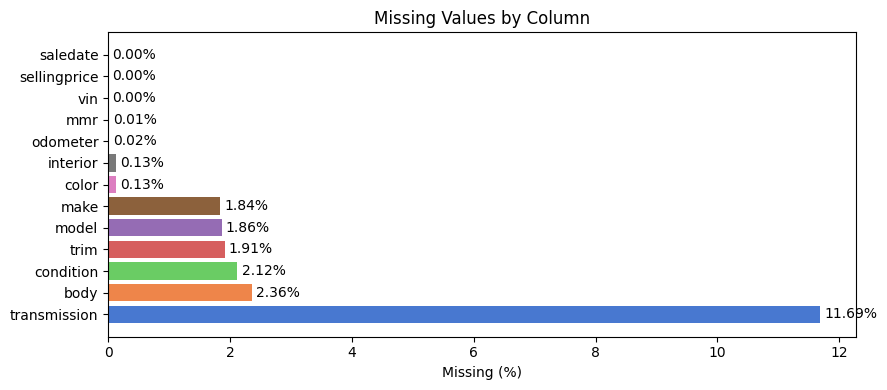

              missing_count  missing_%
transmission          65352      11.69
body                  13195       2.36
condition             11820       2.12
trim                  10651       1.91
model                 10399       1.86
make                  10301       1.84
color                   749       0.13
interior                749       0.13
odometer                 94       0.02
mmr                      38       0.01
vin                       4       0.00
sellingprice             12       0.00
saledate                 12       0.00


In [ ]:
missing = cars_df.isnull().sum()
missing_pct = (missing / len(cars_df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df.index, missing_df['missing_%'], color=sns.color_palette('muted'))
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

print(missing_df.to_string())

In [ ]:
print(missing.sum())

123376


In [ ]:
print(len(cars_df))

558837


## Data Transformations Performed

### Type Casting

In [ ]:
#Casting Sales Date to a datetime column
cars_df['saledate'] = pd.to_datetime(cars_df['saledate'], errors='coerce', utc=True)

/tmp/ipykernel_1468/1916672372.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cars_df['saledate'] = pd.to_datetime(cars_df['saledate'], errors='coerce', utc=True)


### Handling NULLs

In [ ]:
# backfill transmission based on make and model
cars_df['transmission'] = cars_df.groupby(['make','model'])['transmission'].bfill()
cars_df['body'] = cars_df.groupby(['make','model'])['body'].bfill()


In [ ]:
missing = cars_df.isnull().sum()
print(missing.sum())

68856


In [ ]:
# Drop all null values
cars_df.dropna(inplace=True)
print(cars_df.isna().sum())

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64


### Drop Outliers

#### Numerical Outliers

plot outlier decisions

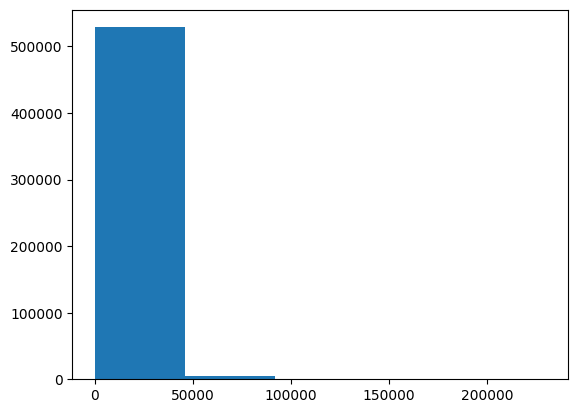

In [ ]:
plt.hist(cars_df['sellingprice'], bins=5)
plt.show()

removing numerical outliers

In [ ]:
cars_df = cars_df[
    (cars_df['year'] > 2004) &
    (cars_df['odometer'] <= 200000) &
    (cars_df['mmr'] <= 100000) &
    (cars_df['sellingprice'] <= 100000)
]

cars_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,476817.0,2011.181632,2.656514,2005.0,2010.0,2012.0,2013.0,2015.0
condition,476817.0,32.002041,13.052951,1.0,26.0,36.0,42.0,49.0
odometer,476817.0,56265.100879,40260.753158,1.0,25574.0,43872.0,80356.0,200000.0
mmr,476817.0,15263.368546,9050.659978,125.0,9400.0,13400.0,19450.0,100000.0
sellingprice,476817.0,15098.480442,9149.705772,1.0,9100.0,13300.0,19300.0,100000.0


#### Categorical Outliers

In [ ]:
cars_df = cars_df[cars_df.groupby('make')['make'].transform('size') > 1000]
cars_df = cars_df[cars_df.groupby(['make','model'])['model'].transform('size') > 100]

In [ ]:
cars_df[['make']].value_counts()

,count
make,
Ford,83293
Chevrolet,52242
Nissan,49254
Toyota,33713
Dodge,27738
Honda,21559
Hyundai,20408
BMW,17338
Kia,17123


In [ ]:
cars_df = cars_df[
    (cars_df['transmission'] == 'automatic')
]


### Derived Columns

#### Drop Unnecessary Columns

In [ ]:
cars_df.drop(columns=['condition', 'transmission','trim','vin','color','interior','seller'])

,year,make,model,body,state,odometer,mmr,sellingprice,saledate
0,2015,Kia,Sorento,SUV,ca,16639.0,20500.0,21500.0,2014-12-16 04:30:00+00:00
1,2015,Kia,Sorento,SUV,ca,9393.0,20800.0,21500.0,2014-12-16 04:30:00+00:00
2,2014,BMW,3 Series,Sedan,ca,1331.0,31900.0,30000.0,2015-01-14 20:30:00+00:00
3,2015,Volvo,S60,Sedan,ca,14282.0,27500.0,27750.0,2015-01-28 20:30:00+00:00
4,2014,BMW,6 Series Gran Coupe,Sedan,ca,2641.0,66000.0,67000.0,2014-12-18 04:30:00+00:00
...,...,...,...,...,...,...,...,...,...
558831,2011,BMW,5 Series,Sedan,fl,66403.0,20300.0,22800.0,2015-07-06 23:15:00+00:00
558833,2012,Ram,2500,Crew Cab,wa,54393.0,30200.0,30800.0,2015-07-08 02:30:00+00:00
558834,2012,BMW,X5,SUV,ca,50561.0,29800.0,34000.0,2015-07-08 02:30:00+00:00
558835,2015,Nissan,Altima,sedan,ga,16658.0,15100.0,11100.0,2015-07-08 23:45:00+00:00


In [ ]:
# Age of the car
cars_df['age'] = 2015 - cars_df['year']

cars_df['sale_year']  = cars_df['saledate'].dt.year
cars_df['sale_month'] = cars_df['saledate'].dt.month

# Derived feature: price vs market value
cars_df['price_vs_mmr'] = cars_df['sellingprice'] - cars_df['mmr']
cars_df['price_ratio']  = cars_df['sellingprice'] / cars_df['mmr'].replace(0, np.nan)

In [ ]:
cars_df['make'] = cars_df['make'].str.lower()
cars_df['model'] = cars_df['model'].str.lower()
cars_df['body'] = cars_df['body'].str.lower()

In [ ]:
cars_df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,interior,seller,mmr,sellingprice,saledate,age,sale_year,sale_month,price_vs_mmr,price_ratio
0,2015,kia,sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,...,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00+00:00,0,2014,12,1000.0,1.048780
1,2015,kia,sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,...,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00+00:00,0,2014,12,700.0,1.033654
2,2014,bmw,3 series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,...,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00+00:00,1,2015,1,-1900.0,0.940439
3,2015,volvo,s60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,...,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00+00:00,0,2015,1,250.0,1.009091
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00+00:00,1,2014,12,1000.0,1.015152


# Analytics Methods & Approach

## Categorical Analysis

### Top Makes by Volume

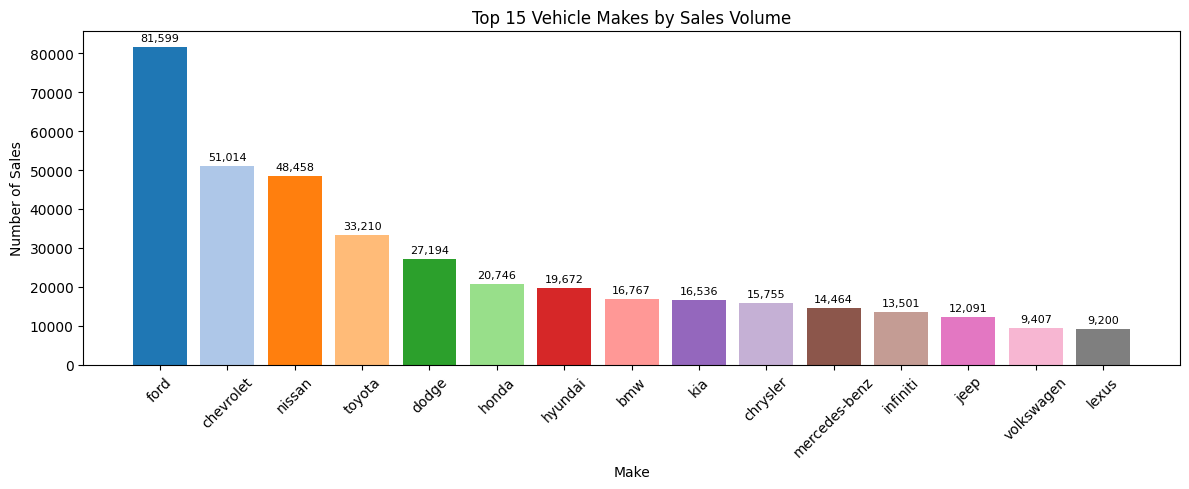

In [ ]:
top_makes = cars_df['make'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_makes.index, top_makes.values, color=sns.color_palette('tab20', 15))
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
ax.set_title('Top 15 Vehicle Makes by Sales Volume')
ax.set_xlabel('Make')
ax.set_ylabel('Number of Sales')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

> **Insight:** **Ford, Chevrolet, and Nissan** dominate auction volume — the typical fleet-vehicle brands. Luxury brands (BMW, Mercedes-Benz) appear in the top 15 but at lower volumes.

Top 15 Brands as a % of total Market

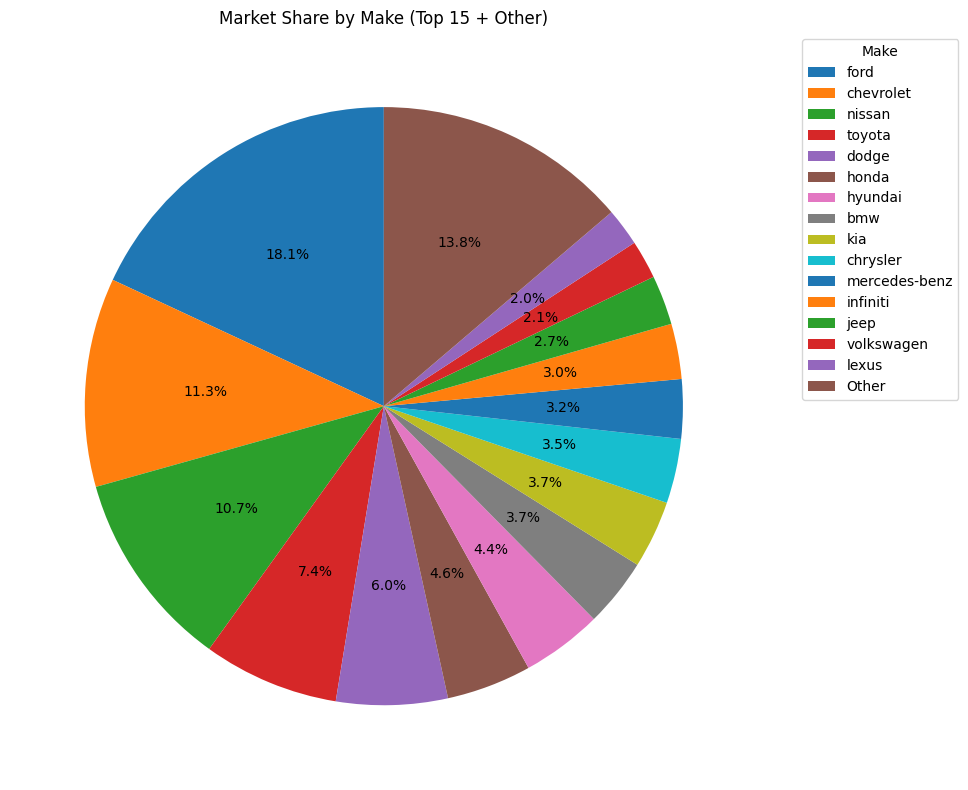

In [ ]:
# Top 15 makes
top_makes = cars_df['make'].value_counts().head(15)

# Everything else
other_count = cars_df['make'].value_counts().iloc[15:].sum()

# Combine
pie_data = pd.concat([
    top_makes,
    pd.Series({'Other': other_count})
])

# Plot
plt.figure(figsize=(12, 8))
plt.pie(
    pie_data,
    labels=None,
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(
    pie_data.index,
    title='Make',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Market Share by Make (Top 15 + Other)')
plt.tight_layout()
plt.show()

### Body Type Distribution
---



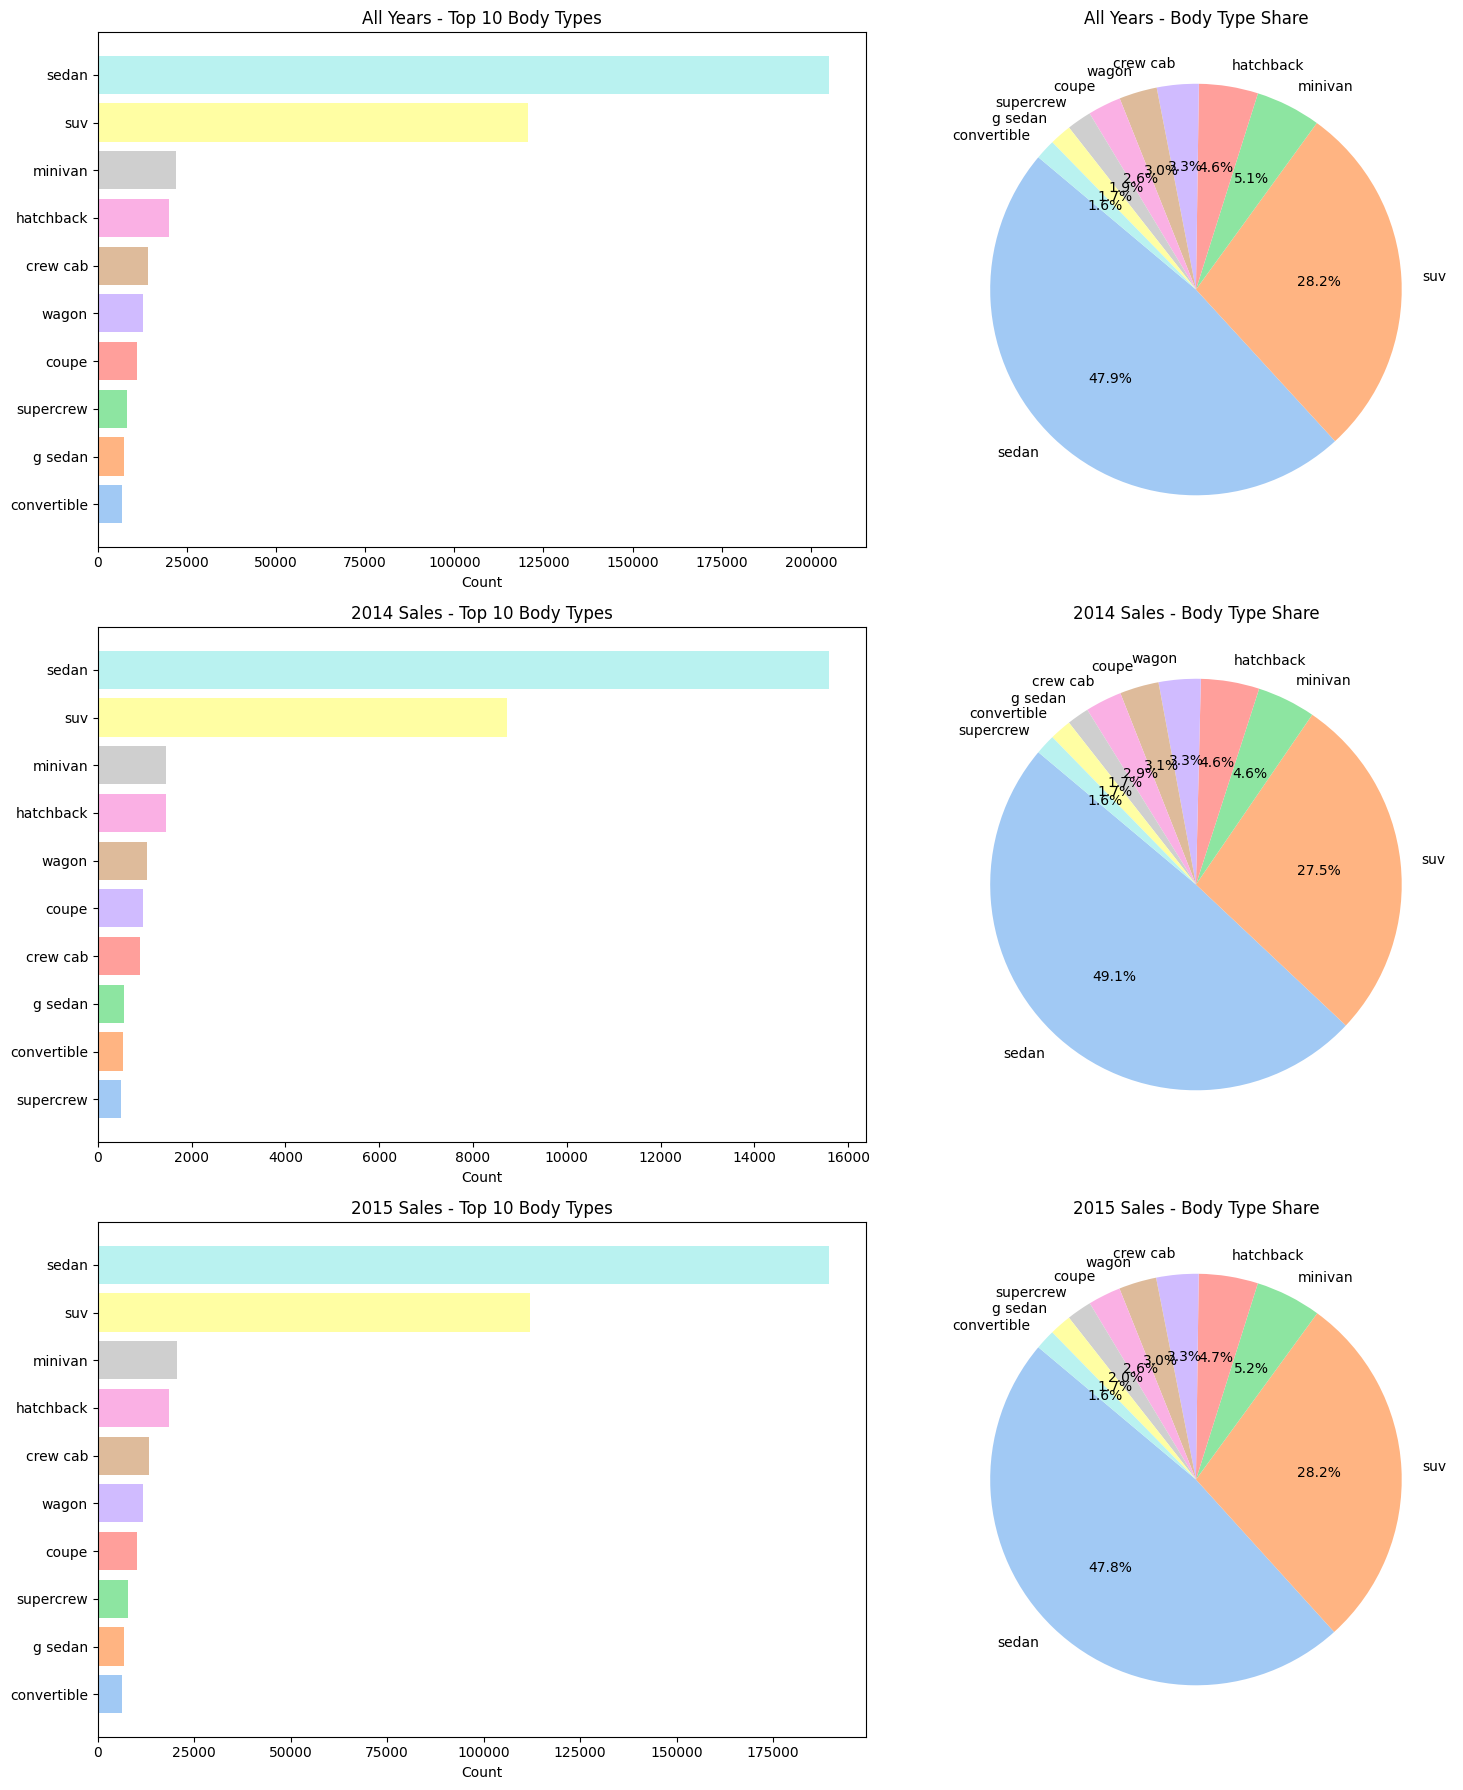

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

datasets = [
    ("All Years", cars_df),
    ("2014 Sales", cars_df[cars_df['sale_year'] == 2014]),
    ("2015 Sales", cars_df[cars_df['sale_year'] == 2015])
]

for row, (title, df) in enumerate(datasets):

    df = df[df['body'] != 'N/A']

    body_counts = (
        df['body']
        .str.lower()
        .value_counts()
        .head(10)
    )

    # Bar chart
    axes[row, 0].barh(
        body_counts.index[::-1],
        body_counts.values[::-1],
        color=sns.color_palette('pastel', len(body_counts))
    )
    axes[row, 0].set_title(f'{title} - Top 10 Body Types')
    axes[row, 0].set_xlabel('Count')

    # Pie chart
    axes[row, 1].pie(
        body_counts.values,
        labels=body_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel', len(body_counts)),
        startangle=140
    )
    axes[row, 1].set_title(f'{title} - Body Type Share')

plt.tight_layout()
plt.show()

:**Sedans and SUVs** together account for the vast majority of sales (~75%)

## Average Selling Price by Make (Top 20)

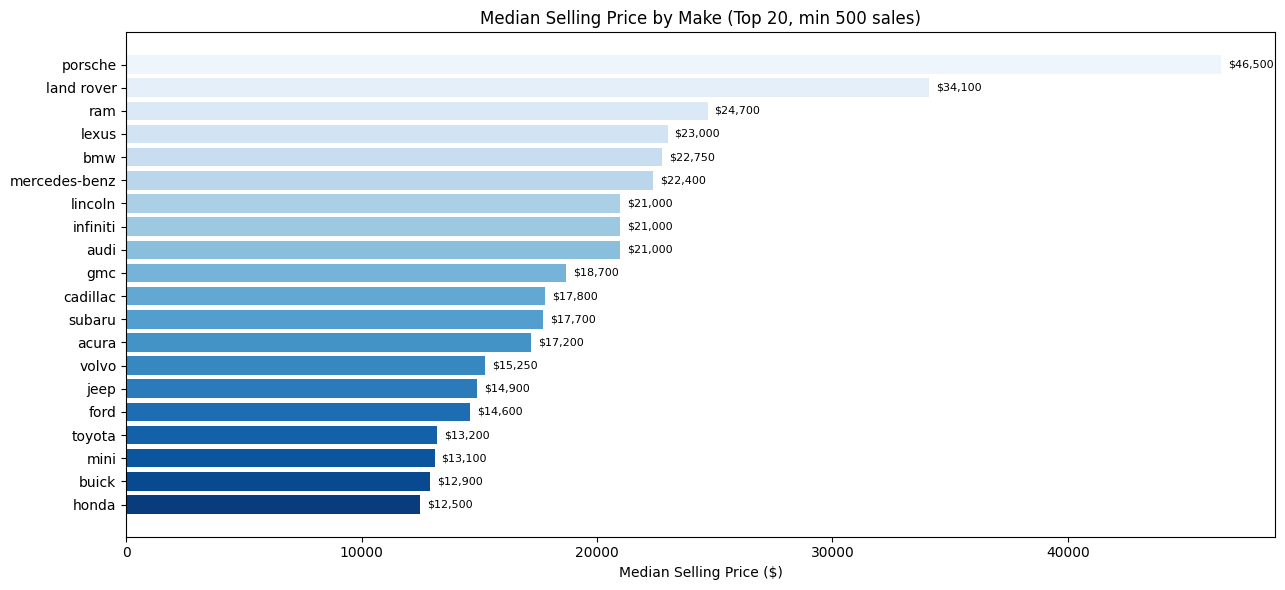

In [ ]:
make_price = (cars_df.groupby('make')['sellingprice']
                .agg(['median', 'count'])
                .query('count >= 500')
                .sort_values('median', ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(make_price.index[::-1], make_price['median'][::-1],
               color=sns.color_palette('Blues_r', 20))
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=8)
ax.set_title('Median Selling Price by Make (Top 20, min 500 sales)')
ax.set_xlabel('Median Selling Price ($)')
plt.tight_layout()
plt.show()

>**Porsche, Land Rover, and RAM** command the highest median auction prices, while economy brands like Toyota and Kia sell at the lowest. This mirrors their retail positioning and residual values.

## Sales by State



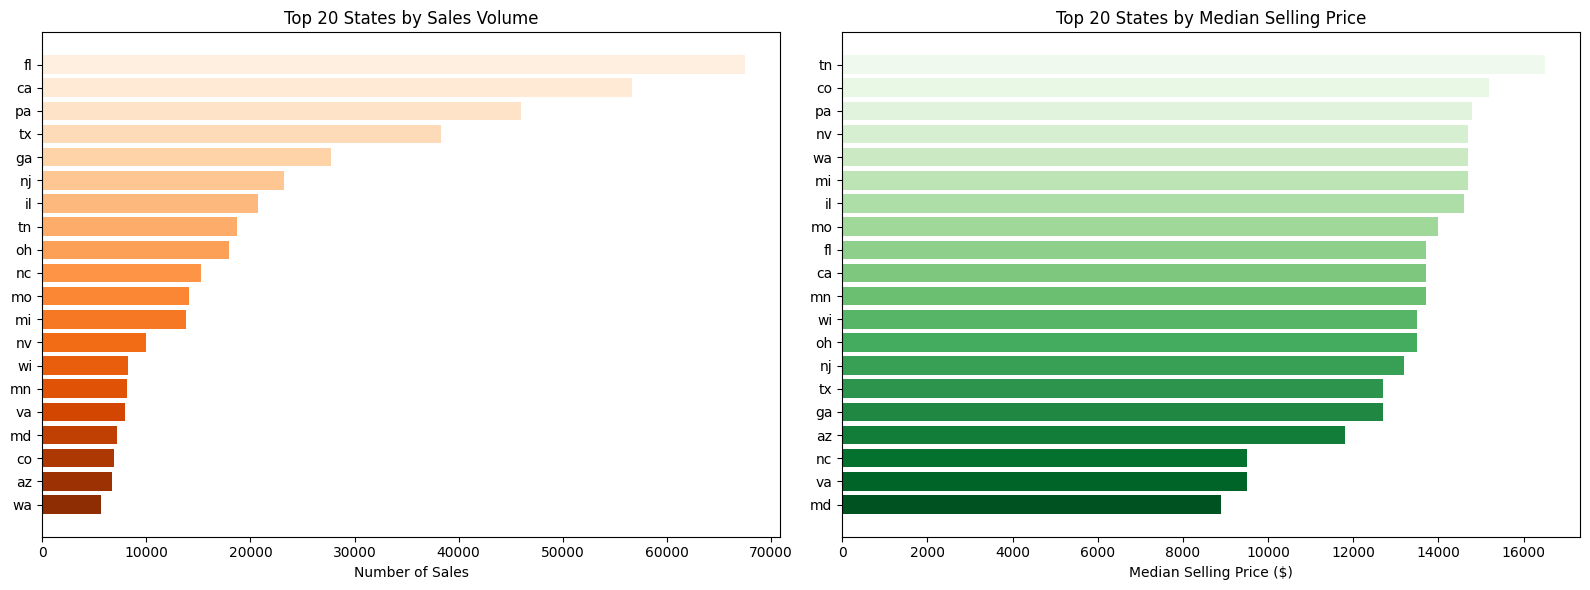

In [ ]:
state_stats = (cars_df.groupby('state')
                 .agg(sales=('sellingprice', 'count'),
                      median_price=('sellingprice', 'median'))
                 .sort_values('sales', ascending=False)
                 .head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume
axes[0].barh(state_stats.index[::-1], state_stats['sales'][::-1],
             color=sns.color_palette('Oranges_r', 20))
axes[0].set_title('Top 20 States by Sales Volume')
axes[0].set_xlabel('Number of Sales')

# Median price
price_by_state = state_stats.sort_values('median_price', ascending=False)
axes[1].barh(price_by_state.index[::-1], price_by_state['median_price'][::-1],
             color=sns.color_palette('Greens_r', 20))
axes[1].set_title('Top 20 States by Median Selling Price')
axes[1].set_xlabel('Median Selling Price ($)')

plt.tight_layout()
plt.show()

> **Insight:** **California (ca)** is the largest auction market by volume, followed by Florida and Pennsylvania. States with higher concentrations of luxury vehicles (e.g., TN, CO) also tend to have higher median selling prices.

## Sales Over Time

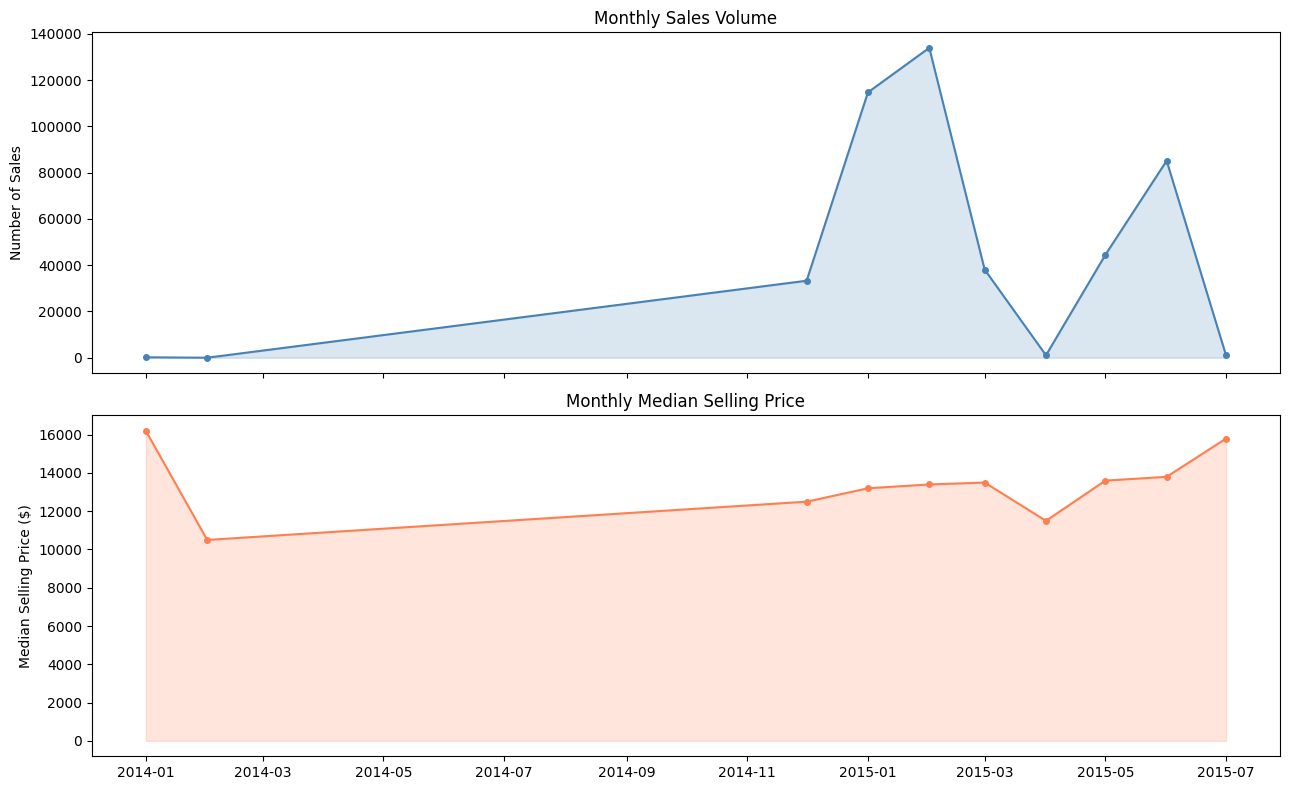

In [ ]:
monthly = (cars_df.dropna(subset=['saledate'])
             .groupby(['sale_year', 'sale_month'])
             .agg(sales=('sellingprice', 'count'),
                  avg_price=('sellingprice', 'median'))
             .reset_index())
monthly['period'] = pd.to_datetime(monthly[['sale_year', 'sale_month']].rename(
    columns={'sale_year': 'year', 'sale_month': 'month'}).assign(day=1))
monthly = monthly.sort_values('period')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(monthly['period'], monthly['sales'], marker='o', markersize=4,
             color='steelblue', linewidth=1.5)
axes[0].fill_between(monthly['period'], monthly['sales'], alpha=0.2, color='steelblue')
axes[0].set_title('Monthly Sales Volume')
axes[0].set_ylabel('Number of Sales')

axes[1].plot(monthly['period'], monthly['avg_price'], marker='o', markersize=4,
             color='coral', linewidth=1.5)
axes[1].fill_between(monthly['period'], monthly['avg_price'], alpha=0.2, color='coral')
axes[1].set_title('Monthly Median Selling Price')
axes[1].set_ylabel('Median Selling Price ($)')

plt.tight_layout()
plt.show()

> **Insight:** Auction **volume grew significantly between 2014–2015**, reflecting post-recession fleet rebound and lease-return cycles. Median prices remained relatively stable, indicating the market efficiently absorbed additional supply without a price crash.

## Correlation Heatmap

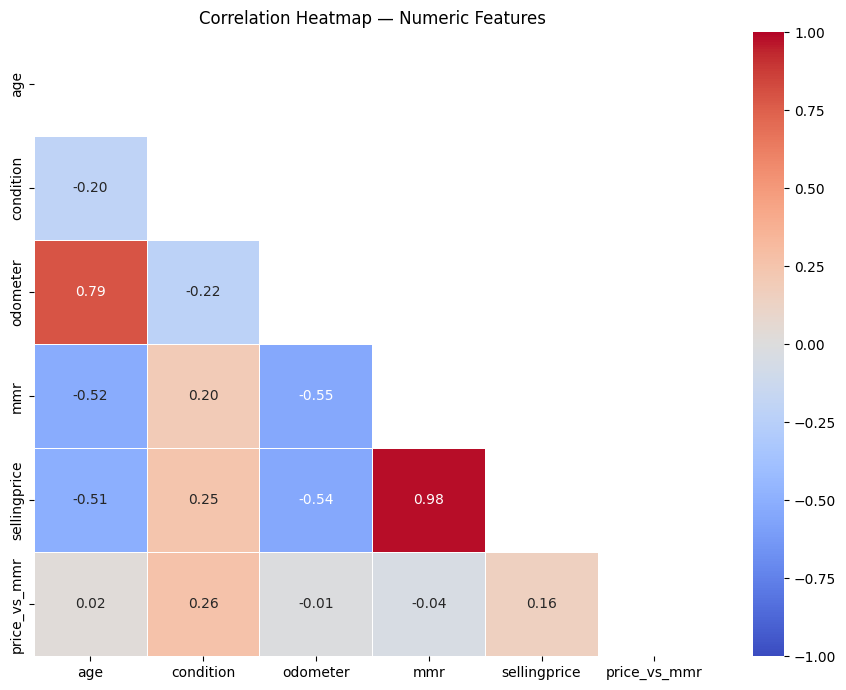

In [ ]:
num_cols = ['age', 'condition', 'odometer', 'mmr', 'sellingprice', 'price_vs_mmr']
corr_matrix = cars_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

> **Key correlations:**
> - `sellingprice` ↔ `mmr`: **+0.98** — market value is the single best predictor of sale price.
> - `sellingprice` ↔ `age`: **-0.55** — newer cars fetch more.
> - `sellingprice` ↔ `odometer`: **−0.57** — higher mileage = lower price.
> - `sellingprice` ↔ `condition`: **+0.49** — better condition commands a premium.
> - `age` ↔ `odometer`: **+0.77** — newer cars unsurprisingly have fewer miles.

# Average Monthly Sales Volume & Average Sales Premium/ Discount relative to MMR

/tmp/ipykernel_1468/3922297840.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  processed_df['year_month'] = processed_df['saledate'].dt.to_period('M')


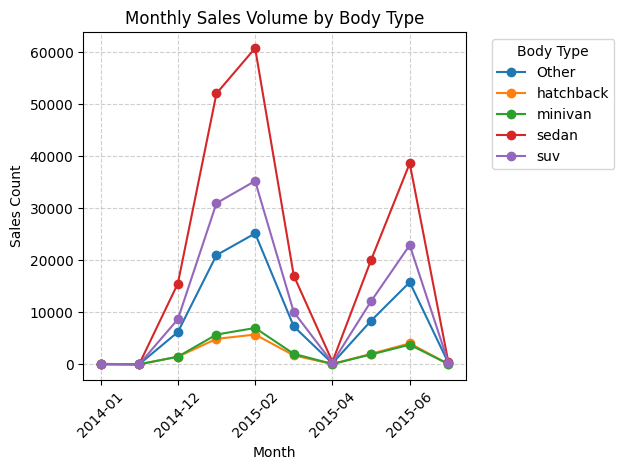

In [ ]:
target_brands = ['suv', 'sedan', 'hatchback', 'minivan']

# saledate column should be a datetime object
cars_df['saledate'] = pd.to_datetime(cars_df['saledate'])

processed_df = cars_df.copy()

# group all body types not in target_brands into 'Other'
processed_df['body'] = processed_df['body'].where(processed_df['body'].isin(target_brands), 'Other')

processed_df['year_month'] = processed_df['saledate'].dt.to_period('M')

# grouping by 'year_month' and 'body', then count total sales via .size()
df_trends = processed_df.groupby(['year_month', 'body']).size().unstack(fill_value=0)

# converting the period index to a string format so matplotlib plots it smoothly
df_trends.index = df_trends.index.astype(str)

df_trends.plot(kind='line', marker='o')

plt.title('Monthly Sales Volume by Body Type')
plt.xlabel('Month')
plt.ylabel('Sales Count')
plt.legend(title='Body Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

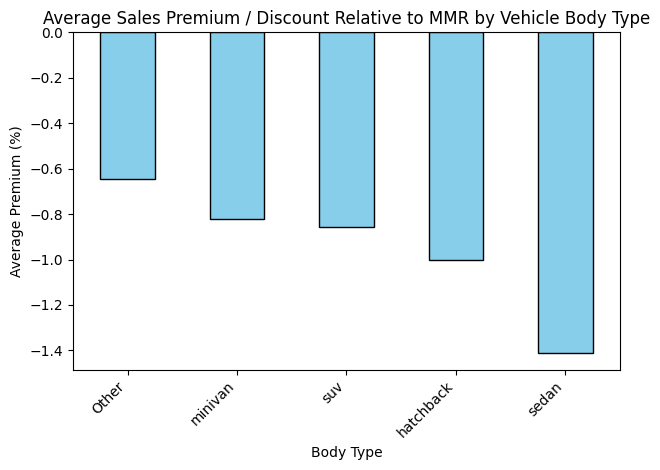

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

target_brands = ['suv', 'sedan', 'hatchback', 'minivan']

valid_mmr_df = cars_df[
    (cars_df['mmr'] > 0) &
    (cars_df['sellingprice'] >= 1000) &
    (cars_df['body'].notna()) &
    (cars_df['body'] != 'n/a')
].copy()

# Map all other body types outside the target list to 'Other'
valid_mmr_df['body'] = valid_mmr_df['body'].where(valid_mmr_df['body'].isin(target_brands), 'Other')

#premium/discount % for each car
valid_mmr_df['premium_pct'] = ((valid_mmr_df['sellingprice'] - valid_mmr_df['mmr']) / valid_mmr_df['mmr']) * 100.0

#Applying a volume filter (minimum 100 units sold) to keep the chart clean
body_counts = valid_mmr_df['body'].value_counts()
valid_bodies = body_counts[body_counts >= 100].index
filtered_df = valid_mmr_df[valid_mmr_df['body'].isin(valid_bodies)]

#calculate the average premium, and sort from highest to lowest
body_premiums = filtered_df.groupby('body')['premium_pct'].mean().sort_values(ascending=False)

body_premiums.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average Sales Premium / Discount Relative to MMR by Vehicle Body Type')
plt.xlabel('Body Type')
plt.ylabel('Average Premium (%)')

# Add a horizontal line at 0% to clearly separate premiums from discounts
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Market Value (MMR)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
cars_df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,interior,seller,mmr,sellingprice,saledate,age,sale_year,sale_month,price_vs_mmr,price_ratio
0,2015,kia,sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,...,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00+00:00,0,2014,12,1000.0,1.048780
1,2015,kia,sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,...,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00+00:00,0,2014,12,700.0,1.033654
2,2014,bmw,3 series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,...,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00+00:00,1,2015,1,-1900.0,0.940439
3,2015,volvo,s60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,...,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00+00:00,0,2015,1,250.0,1.009091
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00+00:00,1,2014,12,1000.0,1.015152


In [ ]:
# Group and get the count of records
result = cars_df.groupby(['sale_year', 'sale_month']).size().reset_index(name='record_count')
print(result)

   sale_year  sale_month  record_count
0       2014           1           175
1       2014           2             1
2       2014          12         33266
3       2015           1        114675
4       2015           2        133925
5       2015           3         38083
6       2015           4          1056
7       2015           5         44426
8       2015           6         85129
9       2015           7          1073
